# Utils

`plot_misc.utils.utils` collects resuable helper function, some of which are used internally by the main plot-misc plotting functions.  
This notebook works through each publichelper in detail, with parameter variations.

For a quick reference version see the corresponding TLDR notebook.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plot_misc.example_data.examples as examples
import plot_misc.heatmap as heatmap
import plot_misc.utils.utils as pm_utils

# centimetres-to-inches 
CMTOINCH = 1 / 2.54

## MidpointNormalize

`MidpointNormalize` is a `matplotlib` normaliser that anchors a chosen value at
the centre of a colour map. For diverging maps (e.g. red/blue) this keeps the
neutral colour pinned to a meaningful reference such as zero, even when the data
range is asymmetric. The left panel below uses matplotlib's default linear
normalisation, zero drifts off the white centre, while the right panel pins
white to zero with `vcenter=0`.

_Note_: symmetrical colours guides, here with -4 and 4, might better convey the difference in magnitude. These automatically do away with centering about zero. 

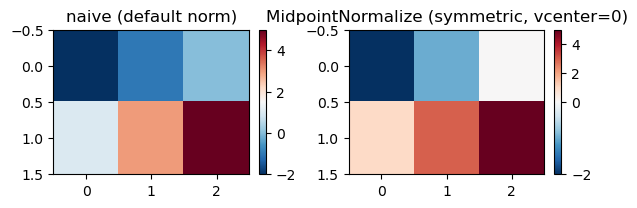

In [2]:
data = np.array([[-2, -1, 0], [1, 3, 5]], dtype=float)

fig, (ax_naive, ax_mid) = plt.subplots(
    1, 2, figsize=(15 * CMTOINCH, 5 * CMTOINCH), layout="constrained"
)

# default linear normalisation: zero is not at the white centre
im0 = ax_naive.imshow(data, cmap="RdBu_r", aspect="auto")
fig.colorbar(im0, ax=ax_naive)
ax_naive.set_title("naive (default norm)")

# MidpointNormalize with symmetric limits (+/- max|data|): white sits at 0 and
# equal +/- magnitudes get equally saturated colours. 
norm = pm_utils.MidpointNormalize(vmin=data.min(), vmax=data.max(), vcenter=0)
im1 = ax_mid.imshow(data, cmap="RdBu_r", norm=norm, aspect="auto")
fig.colorbar(im1, ax=ax_mid)
_ = ax_mid.set_title("MidpointNormalize (symmetric, vcenter=0)")

The midpoint does not have to be zero — set `vcenter` to any reference value
(for example a null odds ratio of 1, or a baseline measurement).

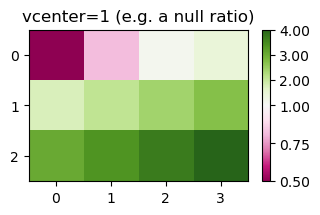

In [3]:
vals = np.linspace(0.5, 4, 12).reshape(3, 4)
norm = pm_utils.MidpointNormalize(vmin=0.5, vmax=4, vcenter=1)

fig, ax = plt.subplots(figsize=(9 * CMTOINCH, 5 * CMTOINCH))
im = ax.imshow(vals, cmap="PiYG", norm=norm, aspect="auto")
# explicit ticks span below and above the midpoint so the colour guide
# shows resolution on both sides of vcenter=1
cbar = fig.colorbar(im, ax=ax, ticks=[0.5, 0.75, 1, 2, 3, 4])
_ = ax.set_title("vcenter=1 (e.g. a null ratio)")

## change_ticks

`change_ticks` sets tick locations and labels in a single call. Two features are
worth highlighting:

- With `log=True` the tick *positions* are placed on a `np.log` scale while the
  *labels* keep the original human-readable values; handy when plotting
  log-transformed effect sizes but labelling them on the natural scale.
- Passing `labels` lets you decouple the displayed text from the numeric tick
  positions entirely.

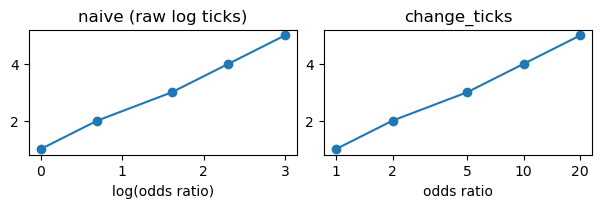

In [4]:
ticks = [1, 2, 5, 10, 20]
fig, (ax_naive, ax_fixed) = plt.subplots(
    1, 2, figsize=(15 * CMTOINCH, 5 * CMTOINCH), layout="constrained"
)
for ax in (ax_naive, ax_fixed):
    ax.plot(np.log(ticks), [1, 2, 3, 4, 5], marker="o")

# naive: the x-axis shows the raw log-transformed positions
ax_naive.set_title("naive (raw log ticks)")
ax_naive.set_xlabel("log(odds ratio)")

# change_ticks: place ticks on the log scale but label the original values
pm_utils.change_ticks(ax_fixed, ticks=ticks, axis="x", log=True)
ax_fixed.set_title("change_ticks")
_ = ax_fixed.set_xlabel("odds ratio")

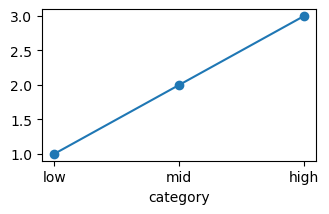

In [5]:
# decoupled text labels via `labels`
fig, ax = plt.subplots(figsize=(9 * CMTOINCH, 5 * CMTOINCH))
ax.plot([10, 20, 30], [1, 2, 3], marker="o")
pm_utils.change_ticks(
    ax, ticks=[10, 20, 30], labels=["low", "mid", "high"], axis="x"
)
_ = ax.set_xlabel("category")

## calc_matrices

`calc_matrices` turns a long-format results table (with exposure, outcome, point
estimate and p-value columns) into heatmap-ready matrices. It returns a small
container exposing three numeric value matrices and several string annotation
layers.

P-values are mapped to three numeric tables:

- `curated_matrix_value` — signed  (`sign(effect) * -log10 p`).
- `curated_matrix_value_unsigned_log` — unsigned `-log10(p)`.
- `curated_matrix_value_raw` — the raw (untransformed) p-values.

The `annotate` argument selects which annotation layer is placed )as strings) in `curated_matrix_annotation`: `'symbol'`
(default), `'pvalues_signed'`, `'pvalues_unsigned'`, `'pvalues_raw'`, or
`'point_estimates'`. 

In [6]:
data = examples.get_data("heatmap_data")
res = pm_utils.calc_matrices(
    data,
    exposure_col="exposure",
    outcome_col="outcome",
    point_col="point",
    pvalue_col="pvalue",
    annotate="symbol",
    alpha=0.05,        # significance cut-off as a raw p-value in (0, 1]
    dropna=True,
)
# the colour matrix is always signed -log10(p)
print("curated_matrix_value (signed -log10 p, for colour):")
display(res.curated_matrix_value.round(2))
# two further numeric tables expose the same p-values on other scales
print("curated_matrix_value_unsigned_log (unsigned -log10 p):")
display(res.curated_matrix_value_unsigned_log.round(2))
print("curated_matrix_value_raw (raw p-values):")
display(res.curated_matrix_value_raw.round(3))
print("annotation layer (significance symbols):")
res.curated_matrix_annotation

curated_matrix_value (signed -log10 p, for colour):


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,0.60,-0.02,3.27,-0.69
LDL-C,-2.28,4.00,0.00,0.00


curated_matrix_value_unsigned_log (unsigned -log10 p):


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,0.60,0.02,3.27,0.69
LDL-C,2.28,4.00,0.00,0.00


curated_matrix_value_raw (raw p-values):


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,0.25,0.95,0.0,0.2
LDL-C,0.01,0.00,1.0,1.0


annotation layer (significance symbols):


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,.,.,★,.
LDL-C,★,★,.,.


The same call with a different `annotate` value swaps the annotation layer
between significance symbols, formatted p-values, and point estimates. The three
`pvalues_*` modes change only the annotation string — the numeric colour matrix
(`curated_matrix_value`) always stays signed `-log10(p)`.

In [7]:
for mode in ["symbol", "pvalues_signed", "pvalues_unsigned",
             "pvalues_raw", "point_estimates"]:
    out = pm_utils.calc_matrices(
        data, exposure_col="exposure", outcome_col="outcome",
        annotate=mode, dropna=True,
    )
    print(f"annotate={mode!r}")
    display(out.curated_matrix_annotation)

annotate='symbol'


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,.,.,★,.
LDL-C,★,★,.,.


annotate='pvalues_signed'


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,.,.,3.27,.
LDL-C,-2.28,4.0,.,.


annotate='pvalues_unsigned'


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,.,.,3.27,.
LDL-C,2.28,4.0,.,.


annotate='pvalues_raw'


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,.,.,0.0,.
LDL-C,0.01,0.0,.,.


annotate='point_estimates'


exposure,IL2ra,IP10,SCF,TRAIL
outcome,,,,
HDL-C,.,.,0.03,.
LDL-C,-0.24,0.03,.,.


The value matrix and an annotation layer can for example be used to create annotated `heatmaps`.
The `annotate="pvalues_signed"` layer overlays the signed $-\log_{10}(p)$ significance score on cells that pass the threshold and a
`.` elsewhere, drawn with `annotate_heatmap`.

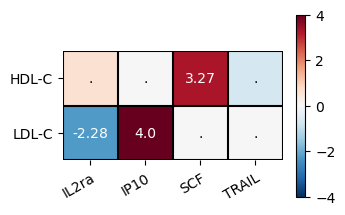

In [8]:
res_p = pm_utils.calc_matrices(
    data, exposure_col="exposure", outcome_col="outcome",
    point_col="point", pvalue_col="pvalue",
    annotate="pvalues_signed", dropna=True,
)
mat = res_p.curated_matrix_value          # signed -log10(p) -> colour
ann = res_p.curated_matrix_annotation     # formatted p-values -> text

fig, ax = plt.subplots(figsize=(9 * CMTOINCH, 6 * CMTOINCH))
col_lim = max(np.abs(mat.values.min()), mat.values.max())
norm = pm_utils.MidpointNormalize(
    vmin=-col_lim, vmax=col_lim, vcenter=0
)
im, _ = heatmap.heatmap(
    data=mat,
    row_labels=mat.index.to_list(),
    col_labels=mat.columns.to_list(),
    ax=ax,
    cmap="RdBu_r",
    norm=norm,
    grid_linewidth=1.5,
    grid_col='black',
)
# overlay the pvalues annotation layer (valfmt=None passes the strings through)
heatmap.annotate_heatmap(im, data=ann, valfmt=None, fontsize=10,)
fig.colorbar(im, ax=ax)

## adjust_labels

`adjust_labels` nudges a list of `ax.annotate` objects apart when they sit closer
than `min_distance`. Each call performs one pairwise pass, so for a tight cluster
you call it repeatedly until the positions stop changing. The left panel shows
the crowded labels, the right panel the result after iterating to convergence.

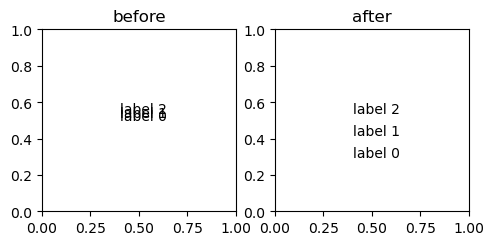

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14 * CMTOINCH, 6 * CMTOINCH))
for ax, title, adjust in zip(axes, ["before", "after"], [False, True]):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    anns = [
        ax.annotate(f"label {i}", (0.4, 0.50 + 0.02 * i)) for i in range(3)
    ]
    if adjust:
        # repeat the pairwise pass until labels stop moving
        for _ in range(5):
            pm_utils.adjust_labels(anns, axis=ax, min_distance=0.12)

## calc_mid_point & calc_angle_points

These are the two geometry primitives used by `segment_labelled`:
`calc_mid_point` returns the Cartesian midpoint of two points and
`calc_angle_points` returns the angle (degrees by default, radians with
`radians=True`) of the segment joining them.

midpoint   : (2.5, 4.0)
angle (deg): 53.1
angle (rad): 0.927


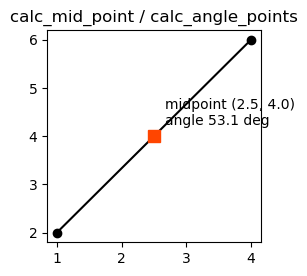

In [10]:
x = (1.0, 4.0)
y = (2.0, 6.0)
mid = pm_utils.calc_mid_point(x, y)
angle = pm_utils.calc_angle_points(x, y)
print("midpoint   :", mid)
print("angle (deg):", round(angle, 1))
print("angle (rad):", round(pm_utils.calc_angle_points(x, y, radians=True), 3))

fig, ax = plt.subplots(figsize=(7 * CMTOINCH, 7 * CMTOINCH))
ax.plot(x, y, marker="o", color="black")
ax.plot(*mid, marker="s", color="orangered", markersize=9)
ax.annotate(
    f"midpoint {mid}\nangle {angle:.1f} deg",
    xy=mid, xytext=(8, 8), textcoords="offset points",
)
_ = ax.set_title("calc_mid_point / calc_angle_points")

## segment_labelled

`segment_labelled` draws a line segment between two points with styled endpoints and an optional label at the midpoint. By default the label is rotated to follow
the segment; internally it measures the segment's on-screen angle with `calc_angle_points` and applies it as the text rotation. 
The rotation can be controlled:

- `overrule_angle` pins the label to a fixed rotation (e.g. `0` for horizontal).
- `calc_angle_after_trans=False` rotates by the data-coordinate angle instead of
  the displayed (pixel) angle.

Endpoint and label styling is exposed through dedicated arguments and the
`kwargs_segment` / `kwargs_text` passthrough dictionaries.

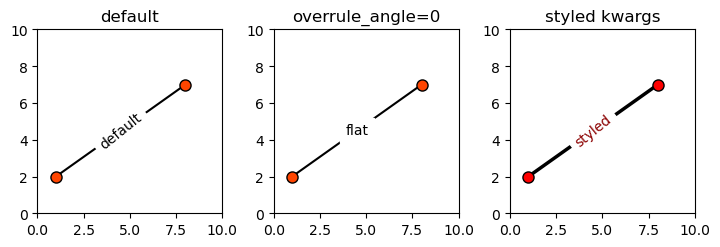

In [11]:
fig, axes = plt.subplots(
    1, 3, figsize=(18 * CMTOINCH, 6 * CMTOINCH), layout="constrained"
)
for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

# default: label rotation follows the segment
pm_utils.segment_labelled(x=(1, 8), y=(2, 7), ax=axes[0], label="default")
axes[0].set_title("default")

# fixed horizontal label
pm_utils.segment_labelled(
    x=(1, 8), y=(2, 7), ax=axes[1], label="flat", overrule_angle=0
)
axes[1].set_title("overrule_angle=0")

# custom endpoint/segment/text styling
pm_utils.segment_labelled(
    x=(1, 8), y=(2, 7), ax=axes[2], label="styled",
    endpoints_c="red", segment_c="black",
    kwargs_segment={"linewidth": 2.5},
    kwargs_text={"color": "darkred"},
)
_ = axes[2].set_title("styled kwargs")

## annotate_axis_midpoints

`annotate_axis_midpoints` labels the midpoint of a gap between ticks on an axis; the typical use is adding bold **section headers** in the blank rows
between subgroups of a forest-style plot. 

It scans the tick positions and, for every pair of consecutive ticks separated by exactly `gap`, places one label at the midpoint. 
Because the labels are drawn `ha='right'`, a small negative `offset` lines their right edge up with the y-tick labels (here `offset=-0.04`,
matching the forest notebook), while `padding` nudges each header along the axis toward the subgroup it heads. 


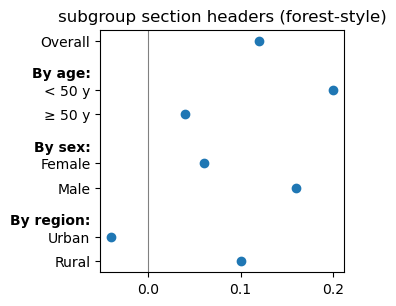

In [12]:
# one "Overall" row, then three subgroups of two rows each. Within-group
# spacing is 1; groups are separated by a gap of 2, so gap=2 finds exactly one
# blank per subgroup.
y = [1, 3, 4, 6, 7, 9, 10]
vals = [0.12, 0.20, 0.04, 0.06, 0.16, -0.04, 0.10]
labels = ["Overall", "< 50 y", "≥ 50 y", "Female", "Male", "Urban", "Rural"]

fig, ax = plt.subplots(figsize=(8 * CMTOINCH, 8 * CMTOINCH))
ax.scatter(vals, y)
ax.axvline(0, color="grey", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()

# bold section headers in the gaps between subgroups. offset=-0.04 keeps the
# header right-edge aligned with the y-tick labels (forest-style); padding
# nudges each header toward the subgroup it heads.
pm_utils.annotate_axis_midpoints(
    ax,
    labels=["By age:", "By sex:", "By region:"],
    axis="y",
    gap=2,
    offset=-0.04,
    padding=0.35,
    text_kwargs={"fontweight": "bold"},
)
_ = ax.set_title("subgroup section headers (forest-style)")


## plot_span

This is simply a wrapper of the matplotlib span function. Including it here incase people find it useful. Mostly an internal function in plot-misc.

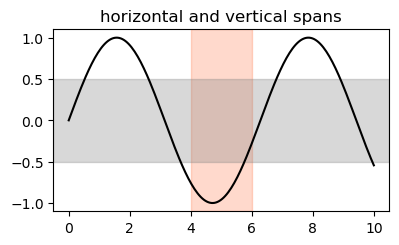

In [13]:
x = np.linspace(0, 10, 200)
fig, ax = plt.subplots(figsize=(11 * CMTOINCH, 6 * CMTOINCH))
ax.plot(x, np.sin(x), color="black")

# horizontal band highlighting a value range (axhspan)
pm_utils.plot_span(-0.5, 0.5, ax=ax, horizontal=True, color="grey", alpha=0.3)
# vertical band highlighting an x range (axvspan), drawn behind the line
pm_utils.plot_span(
    4, 6, ax=ax, horizontal=False, color="orangered", alpha=0.2, zorder=0
)
_ = ax.set_title("horizontal and vertical spans")